# **Week 3 Notebook**
**Lundy Zheng**

This week's tasks revolves around learning essential risk measures and implementing basic portfolio construction methods.

In [61]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
from matplotlib.ticker import PercentFormatter
from adjustText import adjust_text

# May or may not use.
from src.factor_utils import quintile_statistics
from src.factor_utils import factor_statistics
from src.data_utils import load_ohlcv
from src.data_utils import compute_returns
from src.factor_utils import add_cumulative_returns

# Task 1

We start with a simple implementation of a risk metric-computing function, which takes in a dataframe with assigned quintiles from long-short factors, and outputs a list of statistics.
In particular, for last week's work I only used monthly data following the ranking functions since we ranked monthly. Thus, the data inputs I'll have here will be monthly. however, I implement an annualization logic that works for both daily and monthly data (since we only need periods/year for each frequency) by compounding.

For the quintiles each, we start with the inputs from last week:

momentum/value_quintiles
momentum/value_quintiles_dfs

Which lets us do analysis both on the whole set as well as on specific quintiles of data.
For the long-short strategy, we also input:

momentum/value_factor_returns

In addition, we can borrow from the previous functions which already compute much of the needed portfolio statistics.

In [2]:
# Read in our dataframes

value_factor_returns = pd.read_parquet(
    "../data/processed/value_factor_returns.parquet"
)

momentum_factor_returns = pd.read_parquet(
    "../data/processed/momentum_factor_returns.parquet"
)

value_quintiles = pd.read_parquet(
    "../data/processed/value_quintiles.parquet"
)

momentum_quintiles = pd.read_parquet(
    "../data/processed/momentum_quintiles.parquet"
)

value_quintile_dfs = {
    q: value_quintiles[
        value_quintiles["quintile"] == q
    ].copy()
    for q in range(1, 6)
}

momentum_quintile_dfs = {
    q: momentum_quintiles[
        momentum_quintiles["quintile"] == q
    ].copy()
    for q in range(1, 6)
}

momentum_quintile_dfs[1].head()

,ticker,month,monthly_simple_return,next_month_return,momentum,momentum_rank,quintile
39,AAPL,2024-04,-0.006706,0.130222,0.045454,8.0,1
40,AAPL,2024-05,0.130222,0.095553,0.009189,7.0,1
41,AAPL,2024-06,0.095553,0.054411,0.090386,7.0,1
42,AAPL,2024-07,0.054411,0.032353,0.091605,9.0,1
55,AAPL,2025-08,0.119639,0.096881,-0.060966,7.0,1


In [3]:
# Build on the previous functions to make compute_risk_metrics()

def compute_risk_metrics(
    df,
    return_column,
    portfolio_type,
    risk_free_rate=0 
):
    """
    Computes relevant risk metrics for a given dataset with a list of monthly simple returns.
    Can be implemented on both per-quintile portfolios as well as long-short factor portfolios.
    The function has two modes:
        1) if portfolio is a quintile portfolio of stocks, it aggregates different stock data first before computing statistics
        2) if portfolio is the long-short factor return data it computes statistics directly.

    Input:
        df: dataframe - either momentum/value_quintiles_dfs[i] or momentum/value_factor_returns
        return_column: name of return column (str)
        portfolio_type: "quintile" or "factor" (str)
        risk_free_rate: Annual risk-free rate, default = 0 (fl)
    Output:
        pd.series of relevant metric results for the given dataframe
    """

    # --------------------------------------------------
    # 1. Get one monthly return series for the portfolio
    # --------------------------------------------------

    if portfolio_type == "quintile":

        # Assuming each row represents one stock in one month,
        # take the equal-weight average return across stocks.
        returns = (
            df.groupby("month")[return_column]
              .mean()
              .dropna()
        )

    elif portfolio_type == "factor":

        # Factor dataframe already has one return per month
        returns = df[return_column].dropna()

    else:
        raise ValueError(
            "portfolio_type must be 'quintile' or 'factor'"
        )

    # --------------------------------------------------
    # 2. Basic information
    # --------------------------------------------------

    num_months = len(returns)

    # --------------------------------------------------
    # 3. Annualized return
    # --------------------------------------------------

    total_growth = (1 + returns).prod()

    annualized_return = (
        total_growth ** (12 / num_months) - 1
    )

    # --------------------------------------------------
    # 4. Annualized volatility
    # --------------------------------------------------

    monthly_volatility = returns.std()

    annualized_volatility = (
        monthly_volatility * np.sqrt(12)
    )

    # Building on top of these, the other metrics:

    # Skew and Kurt
    skewness = returns.skew()
    kurtosis = returns.kurt()

    # Sharpe, Sortino, Calmar ratios, max drawdown, hit rate,

    sharpe_ratio = (
    (annualized_return - risk_free_rate) / annualized_volatility
    )

    negative_returns = returns[returns < 0]
    downside_deviation = negative_returns.std() * np.sqrt(12)
    sortino_ratio = (
        (annualized_return - risk_free_rate)
        / downside_deviation
    )

    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_drawdown = drawdown.min()

    calmar_ratio = (
        annualized_return / abs(max_drawdown)
    )

    hit_rate = (returns > 0).mean()

    # And return everything:
    metrics = pd.Series({
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "sharpe_ratio": sharpe_ratio,
        "sortino_ratio": sortino_ratio,
        "max_drawdown": max_drawdown,
        "calmar_ratio": calmar_ratio,
        "skewness": skewness,
        "kurtosis": kurtosis,
        "hit_rate": hit_rate
    })

    return metrics

# Implement:
metrics_test = compute_risk_metrics(
    momentum_quintiles,
    "monthly_simple_return",
    "quintile",
    risk_free_rate=0 
)

metrics_test.head(9)

annualized_return        0.278485
annualized_volatility    0.170533
sharpe_ratio             1.633026
sortino_ratio            2.655306
max_drawdown            -0.220079
calmar_ratio             1.265384
skewness                -0.267563
kurtosis                 0.035379
hit_rate                 0.692308
dtype: float64

# Task 2

For this next task, we want to calculate relevant correlation statistics to see how stocks move together, and how much of the portfolio is simply the market.

For the first part, which is the correlation matrices:
    -For stock v stock, we find a correlation value between each two stocks, and we can visualize this via matrix (49x49 for value, 50x50 for momentum).
    -For portfolio v portfoloio, we do the same but using quintiles, so the output will be a 5x5 matrix.

In [4]:
# Stock correlation matrix. Start with momentum_quintiles
def stock_correlation_matrix(
    df,
    return_column="monthly_simple_return",
    ticker_column="ticker",
    date_column="month",
    tickers=None
):
    """
    Computes a stock-level correlation matrix using returns over time (months).

    Input:
        df: dataframe containing stock returns, needs ticker, date, returns (e.g., momentum_quintiles actually suffices)
        return_column: column containing returns used to calculate correlation.
        ticker_column: column identifying each stock.
        date_column: column identifying the return period.

    Output:
        dataframe containing the correlation matrix.
    """

    # Optionally select certain stocks
    if tickers is not None:
        df = df[df[ticker_column].isin(tickers)]
    
    # Reshape from long format:
    # one row per month, one column per stock
    returns_wide = df.pivot(
        index=date_column,
        columns=ticker_column,
        values=return_column
    )

    # Calculate correlations between every pair of stocks
    correlation_matrix = returns_wide.corr()

    returns_wide = df.pivot(
        index=date_column,
        columns=ticker_column,
        values=return_column
    )

    correlation_matrix = returns_wide.corr()

    return correlation_matrix

stock_corr_matrix = stock_correlation_matrix(momentum_quintiles, "monthly_simple_return", "ticker", "month")
stock_corr_matrix.head()

ticker,AAPL,ABBV,AMAT,AMD,AMZN,ANET,AVGO,BAC,BRK-B,CAT,...,RTX,TMUS,TSLA,TXN,UNH,V,VZ,WFC,WMT,XOM
ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.147908,0.353499,0.407763,0.522299,0.466713,0.384306,0.276705,0.363174,0.240618,...,0.000505,0.187258,0.538040,0.339510,0.312205,0.373767,0.016260,0.161297,0.272129,-0.060899
ABBV,0.147908,1.000000,0.082023,-0.082082,-0.213055,0.072860,0.047331,0.143716,0.500107,0.223022,...,0.247308,0.336282,-0.172625,0.065239,0.299106,0.218136,0.186230,0.041407,0.128119,0.101835
AMAT,0.353499,0.082023,1.000000,0.561807,0.469839,0.430664,0.489817,0.388268,0.227225,0.593386,...,0.107732,-0.068856,0.322815,0.488506,0.074094,0.194667,0.124539,0.335278,0.211294,0.124041
AMD,0.407763,-0.082082,0.561807,1.000000,0.635118,0.540591,0.507688,0.226186,-0.051839,0.379677,...,-0.052116,-0.178026,0.246161,0.491122,0.150735,0.131300,-0.047867,0.144536,-0.091280,-0.168723
AMZN,0.522299,-0.213055,0.469839,0.635118,1.000000,0.616410,0.534901,0.349341,0.114991,0.330057,...,-0.065263,0.012143,0.554154,0.456721,0.106704,0.339711,-0.049114,0.347595,0.226662,-0.150569


In [5]:
# Similarly, we can build the portfolio-level correlation matrix using similar code:
def portfolio_correlation_matrix(
    df,
    return_column="monthly_simple_return",
    date_column="month",
    portfolio_column="quintile"
):
    """
    Computes a portfolio-level correlation matrix.

    For each month, the function first calculates the equal-weight
    return of each portfolio/quintile. It then computes correlations
    between the portfolio return series over the full sample period.

    Input:
        df: dataframe containing individual stock returns and portfolio/quintile
        return_column: column containing returns used to calculate correlation.
        date_column: column identifying the return period.
        portfolio_column: column identifying portfolio membership, e.g. "quintile".

    Output:
        dataframe containing portfolio correlations.
    """

    # 1. Calculate one portfolio return for each quintile each month
    portfolio_returns = (
        df.groupby([date_column, portfolio_column])[return_column]
          .mean()
          .reset_index()
    )

    # 2. Convert to wide format:
    # one row per month, one column per quintile
    portfolio_returns_wide = portfolio_returns.pivot(
        index=date_column,
        columns=portfolio_column,
        values=return_column
    )

    # 3. Correlation between quintile portfolios
    correlation_matrix = portfolio_returns_wide.corr()

    return correlation_matrix

momentum_portfolio_corr_matrix = portfolio_correlation_matrix(momentum_quintiles, "monthly_simple_return", "month", "quintile")
value_portfolio_corr_matrix = portfolio_correlation_matrix(value_quintiles, "monthly_simple_return", "month", "quintile")

Now for the second task, we want to compute beta correlation versus the market benchmark. I've used SPY as my benchmark in the past and will continue to do so hereon. Specifically we load in the benchmark ticker:

In [6]:
ohlcv = load_ohlcv("../data/processed/ohlcv.parquet")
spy = ohlcv[ohlcv["ticker"] == "SPY"].copy()
spy_returns = compute_returns(spy)[0]

# And adjust the labels to what we're working with in this section:
spy_returns["date"] = pd.to_datetime(spy_returns["date"])
spy_returns["month"] = spy_returns["date"].dt.to_period("M")

spy_monthly = (
    spy_returns
    .groupby("month")["daily_simple_return"]
    .apply(lambda x: (1 + x.dropna()).prod() - 1) # Compound
    .reset_index(name="benchmark_return")
)

In [7]:
# Now we can calculate beta using the formula I found online, which is just Cov(r_i, r_m) / Var(r_m)
def calculate_benchmark_metrics(
    portfolio_df,
    benchmark_df,
    portfolio_return_column,
    benchmark_return_column="benchmark_return",
    date_column="month",
    periods_per_year=12
):
    """
    Calculates benchmark-relative portfolio statistics.

    Input:
        portfolio_df: dataframe of portfolio
        benchmark_df: dataframe of benchmark stock, usually SPY
        portfolio_return_column: return column name (str)
        benchmark_return_column: benchmark return column name (str)
        date_column: date column name (str)
        periods_per_year: for monthly, 12 (int)
    
    Output:
        beta
        annualized tracking error
        information ratio
    """

    # Align portfolio and benchmark by period
    merged = pd.merge(
        portfolio_df[[date_column, portfolio_return_column]],
        benchmark_df[[date_column, benchmark_return_column]],
        on=date_column,
        how="inner"
    ).dropna()

    portfolio_returns = merged[portfolio_return_column]
    benchmark_returns = merged[benchmark_return_column]

    # Beta
    beta = (
        portfolio_returns.cov(benchmark_returns)
        / benchmark_returns.var()
    )

    # Active returns
    active_returns = portfolio_returns - benchmark_returns

    # Annualized tracking error
    tracking_error = (
        active_returns.std()
        * np.sqrt(periods_per_year)
    )

    # Annualized information ratio
    information_ratio = (
        active_returns.mean()
        / active_returns.std()
        * np.sqrt(periods_per_year)
    )

    return pd.Series({
        "beta": beta,
        "tracking_error": tracking_error,
        "information_ratio": information_ratio
    })

This next part also required me to learn some new concepts, and these are all metrics based on comparison with the benchmark. Specifically:

    -Tracking error, annualized: annualized standard deviation of the active return (which is r - r_benchmark)
    
        -Tells us how much we deviate from the benchmark
        
    -Information ratio: annualized average active return/ annualized tracking error
    
        -Sharpe ratio of active returns, how well did it perform relative to the benchmark
I decided to merge this with my function for calculating beta above, since they use the same inputs

In [8]:
benchmark_metrics = {}

for q in range(1, 6):

    q_returns = (
        momentum_quintile_dfs[q]
        .groupby("month")["next_month_return"]
        .mean()
        .reset_index(name="portfolio_return")
    )

    # next_month_return belongs to the following month
    q_returns["month"] = q_returns["month"] + 1

    benchmark_metrics[q] = calculate_benchmark_metrics(
        q_returns,
        spy_monthly,
        portfolio_return_column="portfolio_return"
    )

benchmark_metrics_df = pd.DataFrame(benchmark_metrics).T

benchmark_metrics_df.index.name = "quintile"

display(benchmark_metrics_df)

,beta,tracking_error,information_ratio
quintile,,,
1,1.248401,0.156293,0.924132
2,0.832343,0.106248,0.917534
3,0.963091,0.078625,0.778469
4,0.986660,0.088903,0.706965
5,1.278973,0.209581,0.805746


The final part of task 2 asks to build diversification curves showing portfolio volatility. This is actually just going to be a # of stocks vs total volatility graph, from 1 to 50 stocks, the portfolio should see decreasing volatility.
To avoid going from A-Z on my portfolio list of tickers, we instead use random sampling, where every iteration we sample an increasing number of random stocks, many times, to compute its volatility.

We can start with the momentum_quintiles dataframe as it contains all the data we need (just the tickers, dates, and returns) and create a function for this.

In [9]:
def diversification_curve(
    df,
    return_column="monthly_simple_return",
    ticker_column="ticker",
    date_column="month",
    n_simulations=50,
    periods_per_year=12
):
    """
    Computes a diversification curve showing how average portfolio volatility changes as the number of stocks in an equal-weight portfolio increases. Doesn't include the graphing part.

    For each portfolio size:
        1. Randomly sample stocks
        2. Form an equal-weight portfolio
        3. Compute annualized volatility
        4. Repeat many times
        5. Average the resulting volatilities

    Inputs:
        df: dataframe containing stock returns; momentum_quintiles works
        return_column: column containing periodic stock returns (str)
        ticker_column: column identifying each stock (str)
        date_column: column identifying each return period (str)
        n_simulations: number of random portfolios generated for each portfolio size (int)
        periods_per_year: 12 for monthly returns, 252 for daily returns (int)

    Output:
        dataframe with number_of_stocks vs average_volatility
    """

    # Convert to wide format:
    # rows = months, columns = stocks
    returns_wide = df.pivot(
        index=date_column,
        columns=ticker_column,
        values=return_column
    )

    # Number of available stocks
    n_stocks = len(returns_wide.columns)

    results = []

    # Try portfolio sizes from 1 stock up to all stocks
    for n in range(1, n_stocks + 1):

        simulated_volatilities = []

        for _ in range(n_simulations):

            # Randomly choose n stocks
            selected_stocks = returns_wide.sample(
                n=n,
                axis=1
            )
            
            # Only use months where all selected stocks have returns
            selected_stocks = selected_stocks.dropna()
            
            # Equal-weight portfolio return each month
            portfolio_returns = selected_stocks.mean(axis=1)
            
            # Annualized volatility
            volatility = (
                portfolio_returns.std()
                * np.sqrt(periods_per_year)
            )

            simulated_volatilities.append(volatility)

        # Average volatility across all random portfolios
        average_volatility = np.mean(simulated_volatilities)

        results.append({
            "number_of_stocks": n,
            "average_volatility": average_volatility
        })

    return pd.DataFrame(results)

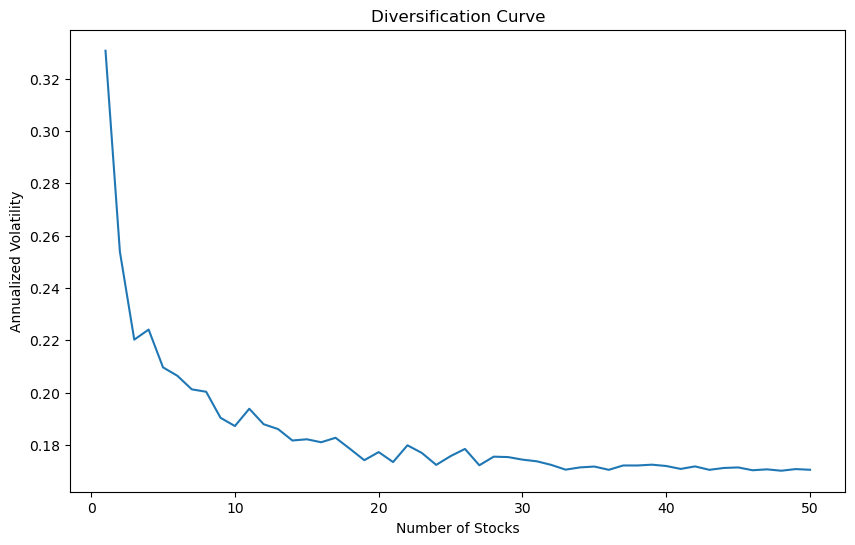

In [10]:
# Now graph this with matplotlib. Didn't build a function for this because this is a pretty one-time thing:

diversification_df = diversification_curve(
    momentum_quintiles,
    n_simulations=50
)

plt.figure(figsize=(10, 6))

plt.plot(
    diversification_df["number_of_stocks"],
    diversification_df["average_volatility"]
)

plt.xlabel("Number of Stocks")
plt.ylabel("Annualized Volatility")
plt.title("Diversification Curve")

plt.show()

# We can see clearly that the volatility doesn't keep going down after ~20 stocks as the residual correlation sets a floor for how low the volatility can get.

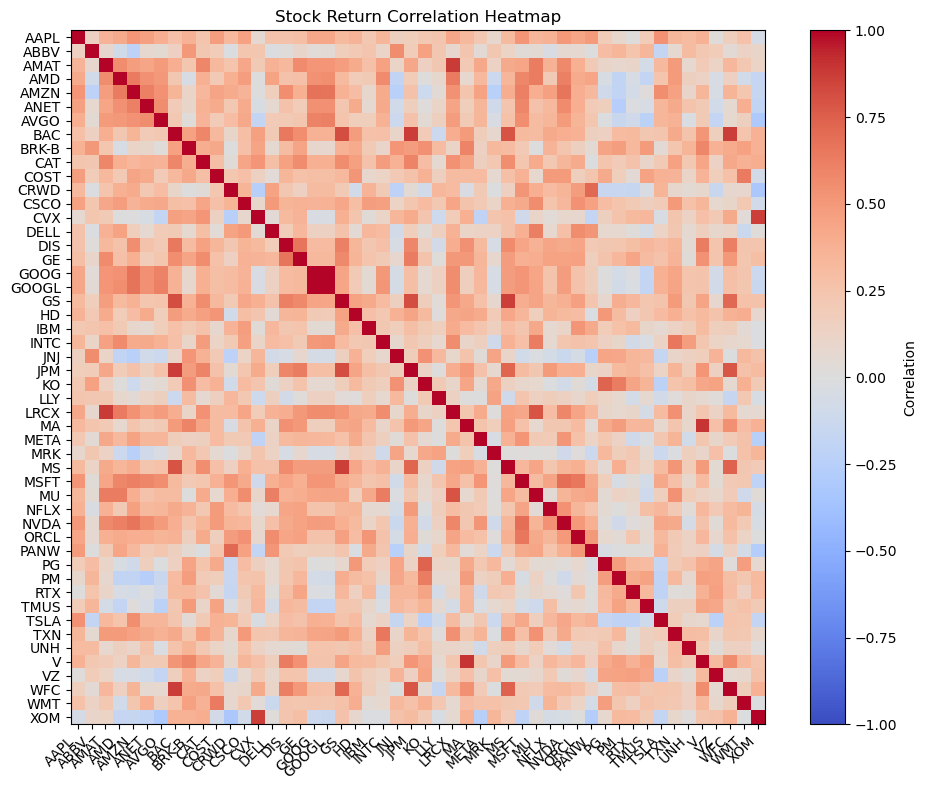

In [11]:
# The other task we've yet to do is to make a correlation heatmap using our previous analysis.
def plot_correlation_heatmap(
    correlation_matrix,
    tickers=None,
    figsize=(10, 8),
    values = True
):
    """
    Plot a correlation heatmap for selected stocks.

    Input:
        correlation_matrix: Stock-level correlation matrix.
        tickers: optional list of stocks to display. If None, displays the full matrix.
        figsize: figure size.
        values: True to display numbers, False to just show colors
    Output:
        heatmap showing correlation between stocks
    """

    if tickers is not None:
        corr = correlation_matrix.loc[tickers, tickers]
    else:
        corr = correlation_matrix

    labels = corr.columns

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        corr,
        vmin=-1,
        vmax=1,
        cmap="coolwarm"
    )

    fig.colorbar(im, ax=ax, label="Correlation")

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)

    # Add correlation values
    if values == True:
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(
                    j,
                    i,
                    f"{corr.iloc[i, j]:.2f}",
                    ha="center",
                    va="center"
                )

    ax.set_title("Stock Return Correlation Heatmap")

    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(stock_corr_matrix, values = False)

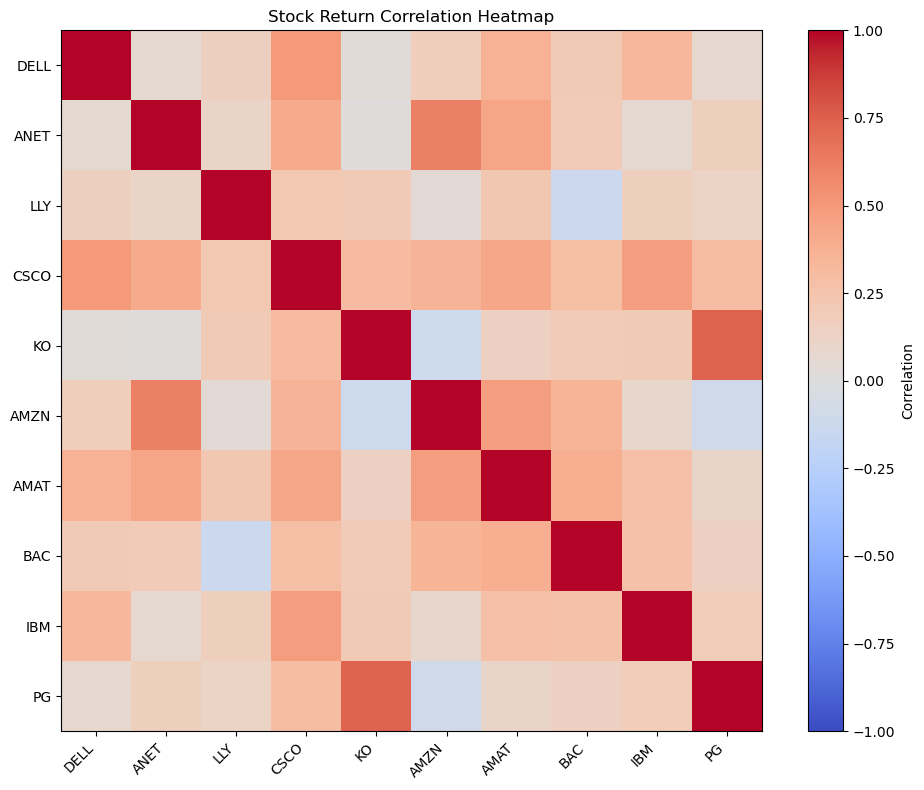

In [12]:
# Random smaller subset with values:

sample_tickers = stock_corr_matrix.columns.to_series().sample(
    n=10
).tolist()
plot_correlation_heatmap(stock_corr_matrix, tickers = sample_tickers, values = False)

# Task 3

Now we actually look at portfolio construction methods. The first one, equal-weight, we've used many times in the past two weeks. The other two: inverse-volatility, and simple risk-parity portfolios we have not.
We work from the OHLCV file and compute returns first, since we need the data starting from 2020-01-01 (for rolling statistics calculation). The first date at which all three portfolios are evaluable will be Feb 2021 for a 12-month window of rolling volatility.
The key here for the sake of construction is to think of an eventual "weight" column that appends to the right of each stock (which totals to 1), which we can use to divide the portfolio up.

In [13]:
# Start by creating the portfolio from OHLCV:

def prepare_monthly_returns(
    ohlcv,
    benchmark_ticker="SPY"
):
    """
    Prepare monthly stock returns for portfolio construction.

    Inputs:
        ohlcv: daily OHLCV dataframe
        benchmark_ticker: ticker to exclude from the portfolio

    Output:
        dataframe containing month, ticker, monthly_simple_return
    """

    df = ohlcv.copy()

    # Exclude benchmark
    df = df[df["ticker"] != benchmark_ticker].copy()

    # Convert date to datetime
    df["date"] = pd.to_datetime(df["date"])

    # Create monthly period
    df["month"] = df["date"].dt.to_period("M")

    # Extract last adjusted close of each month
    monthly_prices = (
        df.sort_values("date")
          .groupby(["ticker", "month"])["adjusted_close"]
          .last()
          .reset_index()
    )

    # Calculate monthly simple returns
    monthly_prices["monthly_simple_return"] = (
        monthly_prices.groupby("ticker")["adjusted_close"]
                      .pct_change(fill_method=None)
    )

    return monthly_prices[
        ["month", "ticker", "monthly_simple_return"]
    ]

ohlcv = load_ohlcv("../data/processed/ohlcv.parquet")

portfolio_df = prepare_monthly_returns(ohlcv)

# And make a reusable function to test eligibility:

def add_portfolio_eligibility(
    df,
    window=12,
    return_column="monthly_simple_return"
):
    """
    Mark stocks eligible for portfolio construction.
    A stock is eligible in month t if it has valid returns
    for all window months immediately preceding t.

    Input:
        df: dataframe containing portfolio weights
        window: rolling window for statistics such as volatility (int)
        return_column: column name for returns (str)
    Output:
        appended column indicating if month is eligible or not
    """

    df = df.copy()

    # Convert to wide format: months x stocks
    returns_wide = df.pivot(
        index="month",
        columns="ticker",
        values=return_column
    ).sort_index()

    # Require consecutive calendar months
    returns_wide = returns_wide.reindex(
        pd.period_range(
            returns_wide.index.min(),
            returns_wide.index.max(),
            freq="M"
        )
    )

    # Count valid returns over the previous window months
    historical_count = (
        returns_wide.notna()
                    .shift(1)
                    .rolling(window, min_periods=window)
                    .sum()
    )

    eligible = historical_count.eq(window)

    # Convert eligibility back to long format
    eligible_long = (
        eligible.stack()
                .rename("eligible")
                .reset_index()
    )

    eligible_long.columns = ["month", "ticker", "eligible"]

    df = df.merge(
        eligible_long,
        on=["month", "ticker"],
        how="left"
    )

    df["eligible"] = df["eligible"].fillna(False)

    return df

# Now the implementation: We must importantly address the look-ahead bias problem discussed last week - one month's data should decide the portfolio weights in the next month.
# Equal-weight is easy, I don't really need a function for this.

portfolio_df["ew_weight"] = (
    1 / portfolio_df.groupby("month")["ticker"].transform("nunique")
)

portfolio_df = add_portfolio_eligibility(
    portfolio_df,
    window=12
)

In [14]:
# For inverse volatility, it makes more sense to define a function, as we want this rolling.
def inverse_volatility_weights(
    df,
    return_column="monthly_simple_return",
    date_column="month",
    ticker_column="ticker",
    window=12
):
    """
    Compute inverse-volatility portfolio weights using
    trailing historical returns.

    Inputs:
        df: dataframe containing monthly stock returns
        return_column: monthly return column (str)
        date_column: month column (str)
        ticker_column: stock identifier (str)
        window: number of historical months used for volatility (rolling)

    Output:
        dataframe with 1)rolling_volatility 2)inv_vol_weight
    """

    df = df.copy()

    # Sort by stock and month
    df = df.sort_values([ticker_column, date_column])

    # Calculate historical rolling volatility for each stock
    df["rolling_volatility"] = (
        df.groupby(ticker_column)[return_column]
          .transform(
              lambda x: x.shift(1).rolling(
                  window=window,
                  min_periods=window
              ).std()
          )
    )

    # Inverse volatility
    df["inverse_volatility"] = (
        1 / df["rolling_volatility"]
    )

    # Normalize weights within each month
    df["inv_vol_weight"] = (
        df["inverse_volatility"]
        /
        df.groupby(date_column)["inverse_volatility"].transform("sum")
    )

    return df

portfolio_df = inverse_volatility_weights(
    portfolio_df,
    window=12
)

portfolio_df.loc[
    ~portfolio_df["eligible"],
    "inv_vol_weight"
] = np.nan

In [15]:
# Now onto risk parity: the meaning of this portfolio distribution is to attempt to give each stock the same contribution of risk to the portfolio.
# From online, the governing formula is RC_i = w_i * (sigma_i * rho_i,p * sigma_p)
    # sigma_i is the asset volatility, rho_i,p is the correlation between the asset and the portfolio, sigma_p is portfolio volatility
# Portfolio volatility is calculated by the square root of the portfolio variance: square root of combined asset variances and pairwise covariances.
# Matrix notation makes this easier to think about (vector of portfolio weights times the cov matrix)
# That said, this implementation is still quite hard since we're looking for the weights conditioning over RC_i's being equal.
# This uses an optimizer from SciPy

def calculate_risk_parity_weights(cov_matrix):
    """
    Calculate long-only equal-risk-contribution portfolio weights.

    Input:
        cov_matrix: covariance matrix of stock returns

    Output:
        pd.Series containing risk-parity weights
    """

    n = len(cov_matrix)
    cov = cov_matrix.to_numpy(dtype=float)

    # Symmetrize and regularize covariance
    cov = (cov + cov.T) / 2

    # Small diagonal regularization for numerical stability
    scale = np.trace(cov) / n
    cov = cov + 1e-4 * scale * np.eye(n)

    # Optimize in log-weights to guarantee positivity
    def objective(y):
        x = np.exp(y)
        return 0.5 * x @ cov @ x - np.sum(y)

    def gradient(y):
        x = np.exp(y)
        return x * (cov @ x) - 1

    # Initial guess based on individual volatilities
    vol = np.sqrt(np.diag(cov))
    x0 = 1 / vol

    result = minimize(
        objective,
        np.log(x0),
        jac=gradient,
        method="L-BFGS-B",
        options={"maxiter": 5000, "ftol": 1e-12}
    )

    if not result.success:
        raise ValueError(result.message)

    x = np.exp(result.x)
    weights = x / x.sum()

    return pd.Series(
        weights,
        index=cov_matrix.index,
        name="rp_weight"
    )

def add_risk_parity_weights(
    df,
    window=12,
    return_column="monthly_simple_return"
):
    """
    Add monthly risk-parity weights using historical covariance.

    Input:
        df: dataframe with month, ticker, monthly_simple_return, eligible
        window: rolling window, usually 12
        return_column: name of return column (str)

    Output:
        dataframe with rp_weight added.
    """

    df = df.copy()
    df["rp_weight"] = np.nan

    # Wide matrix: months x stocks
    returns_wide = df.pivot(
        index="month",
        columns="ticker",
        values=return_column
    ).sort_index()

    # Include missing calendar months explicitly
    returns_wide = returns_wide.reindex(
        pd.period_range(
            returns_wide.index.min(),
            returns_wide.index.max(),
            freq="M"
        )
    )

    # Go through each month
    for month in returns_wide.index:

        # Find eligible stocks for this month
        eligible_stocks = df.loc[
            (df["month"] == month) & df["eligible"],
            "ticker"
        ].tolist()

        if len(eligible_stocks) == 0:
            continue

        # Use only the previous window months
        month_position = returns_wide.index.get_loc(month)

        if month_position < window:
            continue

        historical_returns = returns_wide.iloc[
            month_position - window:month_position
        ][eligible_stocks]

        # Require complete historical observations
        if historical_returns.isna().any().any():
            continue

        # Estimate covariance matrix
        cov_matrix = historical_returns.cov()

        # Calculate risk parity weights
        weights = calculate_risk_parity_weights(cov_matrix)

        # Add weights to the original DataFrame
        mask = df["month"] == month

        df.loc[mask, "rp_weight"] = (
            df.loc[mask, "ticker"].map(weights)
        )

    return df

portfolio_df = add_risk_parity_weights(
    portfolio_df,
    window=12
)

In [16]:
# Check that rp-portfolio works:

sample_month = portfolio_df["month"].max()

weights = (
    portfolio_df.loc[
        portfolio_df["month"] == sample_month,
        ["ticker", "rp_weight"]
    ]
    .dropna()
    .set_index("ticker")["rp_weight"]
)

returns_wide = portfolio_df.pivot(
    index="month",
    columns="ticker",
    values="monthly_simple_return"
).sort_index()

history = returns_wide.loc[
    returns_wide.index < sample_month,
    weights.index
].tail(12)

cov = history.cov()

w = weights.to_numpy()

risk_contributions = w * (cov.to_numpy() @ w)

relative_risk_contributions = (
    risk_contributions / risk_contributions.sum()
)

risk_check = pd.DataFrame({
    "weight": w,
    "risk_contribution": relative_risk_contributions
}, index=weights.index)

# Obscured for less lag
#display(risk_check)

target = 1 / len(weights)

print("Target risk contribution:", target)

print(
    "Maximum deviation:",
    np.max(np.abs(relative_risk_contributions - target))
)

print("Maximum portfolio weight:", weights.max())
print("Sum of weights:", weights.sum())

Target risk contribution: 0.02
Maximum deviation: 0.00108910759563011
Maximum portfolio weight: 0.24387108469108437
Sum of weights: 1.0000000000000002


In [17]:
# Test sample month:
sample_month = portfolio_df["month"].max()

display(
    portfolio_df.loc[
        portfolio_df["month"] == sample_month,
        [
            "ticker",
            "ew_weight",
            "inv_vol_weight",
            "rp_weight"
        ]
    ].sort_values("rp_weight", ascending=False)
)

# Weird that XOM is receiving 24% of the weight of the portfolio.

,ticker,ew_weight,inv_vol_weight,rp_weight
3849,XOM,0.02,0.022997,0.243871
2232,MA,0.02,0.037915,0.185362
2078,LLY,0.02,0.014092,0.047244
1154,DELL,0.02,0.010287,0.039779
692,BRK-B,0.02,0.032968,0.035177
3541,V,0.02,0.031397,0.034064
2386,MRK,0.02,0.017860,0.032732
3695,WFC,0.02,0.031323,0.029884
1847,JNJ,0.02,0.028123,0.022761
923,CRWD,0.02,0.014398,0.022466


In [18]:
# Create a cleaner version of portfolio_df to compute statistics:

weight_columns = [
    "ew_weight",
    "inv_vol_weight",
    "rp_weight"
]

portfolio_clean = (
    portfolio_df[
        ["month", "ticker", "monthly_simple_return"] + weight_columns
    ]
    .dropna()
    .sort_values(["month", "ticker"])
    .reset_index(drop=True)
)

portfolio_clean

,month,ticker,monthly_simple_return,ew_weight,inv_vol_weight,rp_weight
0,2021-02,AAPL,-0.079712,0.02,0.015777,0.013502
1,2021-02,ABBV,0.051327,0.02,0.019533,0.018652
2,2021-02,AMAT,0.224807,0.02,0.012897,0.012258
3,2021-02,AMD,-0.013195,0.02,0.011015,0.012533
4,2021-02,AMZN,-0.035328,0.02,0.018131,0.020554
...,...,...,...,...,...,...
3195,2026-05,V,-0.008499,0.02,0.031397,0.034064
3196,2026-05,VZ,-0.004580,0.02,0.027184,0.010648
3197,2026-05,WFC,-0.051644,0.02,0.031323,0.029884
3198,2026-05,WMT,-0.120966,0.02,0.037288,0.021463


In [19]:
# Now we compute monthly returns for each of the portfolios based on their weights, and three new columns will be appended. Since the weights are already computed, these can be treated systematically.

def calculate_portfolio_returns(
    df,
    weight_methods,
    return_column="monthly_simple_return"
):
    """
    Calculate monthly portfolio returns for multiple
    allocation methods.

    Input:
        df: dataframe containing portfolio returns
        weight_methods: dictionary containing column names for multiple portfolios
        return_column: column of monthly simple return
    """

    df = df.copy()

    for weight_col, portfolio_return_col in weight_methods.items():
        df[portfolio_return_col] = (
            df[weight_col] * df[return_column]
        )

    portfolio_returns = (
        df.groupby("month")[list(weight_methods.values())]
        .sum()
        .reset_index()
    )

    return portfolio_returns

weight_methods = {
    "ew_weight": "ew_return",
    "inv_vol_weight": "inv_vol_return",
    "rp_weight": "rp_return"
}
portfolio_returns = calculate_portfolio_returns(portfolio_clean, weight_methods, "monthly_simple_return")

# Add cumulative returns using last week's function

for item in weight_methods.values():
    portfolio_returns = add_cumulative_returns(
        portfolio_returns,
        item,
        "cumulative_" + item
    )

display(portfolio_returns)

,month,ew_return,inv_vol_return,rp_return,cumulative_ew_return,cumulative_inv_vol_return,cumulative_rp_return
0,2021-02,0.055577,0.045170,0.040370,0.055577,0.045170,0.040370
1,2021-03,0.040106,0.047842,0.042831,0.097912,0.095173,0.084930
2,2021-04,0.046207,0.042360,0.037994,0.148643,0.141565,0.126151
3,2021-05,0.021602,0.021979,0.022109,0.173456,0.166656,0.151049
4,2021-06,0.026150,0.019119,0.023253,0.204142,0.188961,0.177814
...,...,...,...,...,...,...,...
59,2026-01,0.047489,0.040723,0.054174,2.103710,1.695950,1.801179
60,2026-02,0.000962,0.008360,0.024074,2.106695,1.718489,1.868614
61,2026-03,-0.039132,-0.040351,-0.035574,1.985123,1.608796,1.766565
62,2026-04,0.139888,0.094345,0.049177,2.402705,1.854924,1.902617


In [20]:
# Now compute statistics using our function from task 1:

performance = {}

for column in weight_methods.values():
    performance[column] = compute_risk_metrics(
        portfolio_returns,
        return_column=column,
        portfolio_type="factor"
    )

performance_df = pd.DataFrame(performance).T

# Also add beta (use previous function) + information ratio & tracking error

benchmark_metrics = {}

for column in ["ew_return", "inv_vol_return", "rp_return"]:
    benchmark_metrics[column] = calculate_benchmark_metrics(
        portfolio_returns,
        spy_monthly,
        portfolio_return_column=column
    )

benchmark_metrics_df = pd.DataFrame(benchmark_metrics).T

performance_df = performance_df.join(benchmark_metrics_df)

In [21]:
# Next up is turnover, which is the amount of the portfolio we need to trade upon rebalancing. We should implement a function for this:

def calculate_turnover(
    df,
    weight_column,
    return_column="monthly_simple_return"
):
    """
    Calculate monthly portfolio turnover.

    Assumes:
        - Weights are target weights held during each month.
        - Monthly rebalancing.
        - Fully invested, long-only portfolio.

    Returns:
        DataFrame containing month and turnover.
    """

    df = df.sort_values(["month", "ticker"]).copy()

    # Create wide matrices: months x stocks
    weights = df.pivot(
        index="month",
        columns="ticker",
        values=weight_column
    ).fillna(0)

    returns = df.pivot(
        index="month",
        columns="ticker",
        values=return_column
    ).reindex(
        index=weights.index,
        columns=weights.columns
    )

    # Previous month's target weights
    previous_weights = weights.shift(1)

    # Previous month's stock returns
    previous_returns = returns.shift(1)

    # Value of each position after market movement
    drifted_values = previous_weights * (1 + previous_returns)

    # Normalize to obtain pre-rebalancing weights
    pretrade_weights = drifted_values.div(
        drifted_values.sum(axis=1),
        axis=0
    )

    # Compare target and pretrade weights
    turnover = (
        0.5 * (weights - pretrade_weights).abs().sum(axis=1)
    )

    # First month has no previous holdings to compare
    turnover.iloc[0] = np.nan

    return turnover.reset_index(name="turnover")

weight_methods = {
    "ew_weight": "ew_return",
    "inv_vol_weight": "inv_vol_return",
    "rp_weight": "rp_return"
}

turnover_results = {}

for weight_col, return_col in weight_methods.items():

    turnover_df = calculate_turnover(
        portfolio_clean,
        weight_column=weight_col
    )

    turnover_results[return_col] = turnover_df["turnover"].mean()

for column, avg_turnover in turnover_results.items():
    performance_df.loc[column, "avg_monthly_turnover"] = avg_turnover

display(performance_df)

# Interesting results - ew had the best sharpe ratio and annualized returns, whilst risk-parity had the lowest volatility and smallest max_drawdown. However, higher turnover suggests the rp portfolio will incur more trading costs.

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,skewness,kurtosis,hit_rate,beta,tracking_error,information_ratio,avg_monthly_turnover
ew_return,0.284363,0.171505,1.658050,2.718943,-0.220079,1.292095,-0.290282,0.023918,0.703125,1.061894,0.048209,2.218896,0.029801
inv_vol_return,0.231616,0.148265,1.562178,2.643530,-0.214268,1.080964,-0.594565,-0.010265,0.734375,0.927092,0.037305,1.627437,0.042563
rp_return,0.236656,0.145256,1.629232,2.736707,-0.203559,1.162590,-0.725661,-0.014356,0.734375,0.860257,0.061080,1.055363,0.156130


# Task 4

Now we move on to Mean-Variance Optimization - which is a special means of portfolio construction by optimizing a mathematical item rather than the simpler methods of portfolio construction we saw earlier.
In particular, mean-variance optimization considers the portfolio's expected returns.
The task also has us thinking about efficient frontiers - this concept we've encountered in economics, but essentially we're looking for a range of portfolios that are optimized in terms of portfolio risk and expected return.

We add some constraints:

1) we consider a long-only portfolio so the weights sum to 1 and range from 0 to 1
2) To avoid optimization cases where the portfolio wants us to put all our money in a few stocks, we also set a cap of 0.1 on individual stock weight.

We first use 12 months of data to estimate expected returns (since we have to align this strategy with the previous ones in terms of time). We attempt to optimize by finding the minimum-variance portfolio

In [22]:
# Minimizing variance: recall our method of finding total variance. We now minimize this quantity rather than seeking equal risk:

def calculate_min_variance_weights(
    cov_matrix,
    max_weight=0.10
):
    """
    Calculate long-only minimum-variance portfolio weights.

    Input:
        cov_matrix: covariance matrix of stock returns
        max_weight: maximum allocation to any individual stock

    Output:
        pd.Series of optimal portfolio weights
    """

    n = len(cov_matrix)
    cov = cov_matrix.to_numpy(dtype=float)

    # Initial guess: equal weights
    initial_weights = np.ones(n) / n

    # Objective: minimize portfolio variance
    def objective(weights):
        return weights @ cov @ weights

    # Gradient of portfolio variance
    def gradient(weights):
        return 2 * cov @ weights

    # Constraint: weights sum to 1
    constraints = {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }

    # Long-only and maximum-weight constraints
    bounds = [(0, max_weight)] * n

    # Check feasibility
    if n * max_weight < 1 - 1e-10:
        raise ValueError(
            "Maximum weight too small for the number of stocks."
        )

    result = minimize(
        objective,
        initial_weights,
        jac=gradient,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": 2000,
            "ftol": 1e-12
        }
    )

    if not result.success:
        raise ValueError(
            f"Optimization failed: {result.message}"
        )

    return pd.Series(
        result.x,
        index=cov_matrix.index,
        name="min_var_weight"
    )


# Test for one month
sample_month = portfolio_df["month"].max()

returns_wide = (
    portfolio_df.pivot(
        index="month",
        columns="ticker",
        values="monthly_simple_return"
    )
    .sort_index()
)

# Select stocks eligible in the sample month
eligible_stocks = portfolio_df.loc[
    (portfolio_df["month"] == sample_month)
    & (portfolio_df["eligible"]),
    "ticker"
].tolist()

# Use the previous 12 months
history = returns_wide.loc[
    returns_wide.index < sample_month,
    eligible_stocks
].tail(12)

cov_matrix = history.cov()

min_var_weights = calculate_min_variance_weights(
    cov_matrix,
    max_weight=0.10
)

display(
    min_var_weights.sort_values(ascending=False)
)

ticker
CVX      1.000000e-01
JNJ      1.000000e-01
WFC      1.000000e-01
XOM      1.000000e-01
MA       1.000000e-01
V        1.000000e-01
WMT      8.968079e-02
MRK      8.483562e-02
CRWD     7.127201e-02
BRK-B    6.973369e-02
DELL     3.472399e-02
AMZN     2.312870e-02
ORCL     1.896658e-02
AMD      7.658638e-03
COST     7.084699e-18
NFLX     6.261756e-18
LLY      5.040571e-18
ABBV     4.939493e-18
CSCO     3.314311e-18
KO       2.536459e-18
DIS      2.487541e-18
PANW     2.363781e-18
HD       1.677914e-18
IBM      1.344103e-18
RTX      1.219135e-18
GOOG     1.127599e-18
PG       1.111673e-18
LRCX     1.110580e-18
UNH      1.066741e-18
META     1.048757e-18
GS       1.024737e-18
CAT      9.830749e-19
TMUS     7.973837e-19
GOOGL    7.966959e-19
PM       5.989376e-19
MS       4.160864e-19
AMAT     2.383784e-19
GE       0.000000e+00
AAPL     0.000000e+00
ANET     0.000000e+00
BAC      0.000000e+00
AVGO     0.000000e+00
MU       0.000000e+00
MSFT     0.000000e+00
INTC     0.000000e+00
JPM

In [23]:
# These statistics are too good to be true! We're using such a large covariance matrix sampling only 12 months, that it seems like the optimizer is able to find means of exploiting this.

print("Sum of weights:", min_var_weights.sum())
print("Minimum weight:", min_var_weights.min())
print("Maximum weight:", min_var_weights.max())
print("Number of zero weights:", (min_var_weights < 1e-8).sum())

w_min = min_var_weights.to_numpy()

w_ew = np.ones(len(cov_matrix)) / len(cov_matrix)

cov = cov_matrix.to_numpy()

min_var_vol = np.sqrt(w_min @ cov @ w_min) * np.sqrt(12)
ew_vol = np.sqrt(w_ew @ cov @ w_ew) * np.sqrt(12)

print("Minimum variance annualized volatility:", min_var_vol)
print("Equal weight annualized volatility:", ew_vol)

Sum of weights: 1.0000000000000002
Minimum weight: 0.0
Maximum weight: 0.1
Number of zero weights: 36
Minimum variance annualized volatility: 0.021655794243361486
Equal weight annualized volatility: 0.16483158286911356


In [24]:
# Instead try diagonal shrinkage, so that we can find a more diversified portfolio. We add both of these to our portfolio list

cov = cov_matrix.to_numpy()

shrinkage = 0.2

diagonal = np.diag(np.diag(cov))

shrunk_cov = (
    (1 - shrinkage) * cov
    + shrinkage * diagonal
)

shrunk_cov_matrix = pd.DataFrame(
    shrunk_cov,
    index=cov_matrix.index,
    columns=cov_matrix.columns
)

shrunk_weights = calculate_min_variance_weights(
    shrunk_cov_matrix,
    max_weight=0.10
)

w_shrunk = shrunk_weights.to_numpy()

print(
    "Original min-var volatility:",
    np.sqrt(w_min @ cov @ w_min) * np.sqrt(12)
)

print(
    "Shrunk min-var volatility:",
    np.sqrt(w_shrunk @ shrunk_cov @ w_shrunk) * np.sqrt(12)
)

print(
    "Number of zero weights after shrinkage:",
    (shrunk_weights < 1e-8).sum()
)

Original min-var volatility: 0.021655794243361486
Shrunk min-var volatility: 0.03295606233098342
Number of zero weights after shrinkage: 27


In [25]:
def add_min_variance_weights(
    df,
    window=12,
    max_weight=0.10,
    shrinkage=0.20,
    return_column="monthly_simple_return"
):
    """
    Add rolling minimum-variance portfolio weights. Uses historical returns only, with monthly rebalancing.
    Also includes shrinkage term for reducing the covariance matrix as an option, due to the large null space of the covariance matrix causing exploits with low # of stocks and very low volatility.

    Outputs:
        min_var_weight
        shrunk_min_var_weight
    """

    df = df.copy()

    df["min_var_weight"] = np.nan
    df["shrunk_min_var_weight"] = np.nan

    # Monthly return matrix: months x stocks
    returns_wide = (
        df.pivot(
            index="month",
            columns="ticker",
            values=return_column
        )
        .sort_index()
    )

    # Ensure the timeline includes all calendar months
    returns_wide = returns_wide.reindex(
        pd.period_range(
            returns_wide.index.min(),
            returns_wide.index.max(),
            freq="M"
        )
    )

    # Iterate through each month
    for month_position in range(window, len(returns_wide)):

        month = returns_wide.index[month_position]

        # Select eligible stocks for this month
        eligible_stocks = df.loc[
            (df["month"] == month) & df["eligible"],
            "ticker"
        ].tolist()

        if len(eligible_stocks) == 0:
            continue

        # Historical returns: previous 12 months
        history = returns_wide.iloc[
            month_position - window:month_position
        ][eligible_stocks]

        # Require complete historical observations
        if history.isna().any().any():
            continue

        # Original sample covariance
        cov_matrix = history.cov()

        # Diagonal shrinkage
        cov = cov_matrix.to_numpy()

        diagonal = np.diag(np.diag(cov))

        shrunk_cov = (
            (1 - shrinkage) * cov
            + shrinkage * diagonal
        )

        shrunk_cov_matrix = pd.DataFrame(
            shrunk_cov,
            index=cov_matrix.index,
            columns=cov_matrix.columns
        )

        # Original minimum-variance weights
        original_weights = calculate_min_variance_weights(
            cov_matrix,
            max_weight=max_weight
        )

        # Shrunk minimum-variance weights
        shrunk_weights = calculate_min_variance_weights(
            shrunk_cov_matrix,
            max_weight=max_weight
        )

        # Append weights to the dataframe
        mask = df["month"] == month

        df.loc[mask, "min_var_weight"] = (
            df.loc[mask, "ticker"].map(original_weights)
        )

        df.loc[mask, "shrunk_min_var_weight"] = (
            df.loc[mask, "ticker"].map(shrunk_weights)
        )

    return df

portfolio_df = add_min_variance_weights(
    portfolio_df,
    window=12,
    max_weight=0.10,
    shrinkage=0.20
)

In [26]:
# Compute all the statistics and update what we had from task 3

weight_columns = [
    "ew_weight",
    "inv_vol_weight",
    "rp_weight",
    "min_var_weight",
    "shrunk_min_var_weight"
]

portfolio_clean = (
    portfolio_df[
        ["month", "ticker", "monthly_simple_return"]
        + weight_columns
    ]
    .dropna()
    .sort_values(["month", "ticker"])
    .reset_index(drop=True)
)

weight_methods = {
    "ew_weight": "ew_return",
    "inv_vol_weight": "inv_vol_return",
    "rp_weight": "rp_return",
    "min_var_weight": "min_var_return",
    "shrunk_min_var_weight": "shrunk_min_var_return"
}

portfolio_returns = calculate_portfolio_returns(
    portfolio_clean,
    weight_methods,
    "monthly_simple_return"
)

# Calculate cumulative returns for all five portfolios
for item in weight_methods.values():
    portfolio_returns = add_cumulative_returns(
        portfolio_returns,
        item,
        "cumulative_" + item
    )

,month,ew_return,inv_vol_return,rp_return,min_var_return,shrunk_min_var_return,cumulative_ew_return,cumulative_inv_vol_return,cumulative_rp_return,cumulative_min_var_return,cumulative_shrunk_min_var_return
0,2021-02,0.055577,0.045170,0.040370,0.010531,0.013080,0.055577,0.045170,0.040370,0.010531,0.013080
1,2021-03,0.040106,0.047842,0.042831,0.041337,0.042056,0.097912,0.095173,0.084930,0.052304,0.055686
2,2021-04,0.046207,0.042360,0.037994,0.028295,0.034665,0.148643,0.141565,0.126151,0.082079,0.092281
3,2021-05,0.021602,0.021979,0.022109,0.018353,0.020688,0.173456,0.166656,0.151049,0.101938,0.114878
4,2021-06,0.026150,0.019119,0.023253,0.018103,0.017730,0.204142,0.188961,0.177814,0.121887,0.134645
...,...,...,...,...,...,...,...,...,...,...,...
59,2026-01,0.047489,0.040723,0.054174,0.036494,0.031878,2.103710,1.695950,1.801179,1.960641,1.792402
60,2026-02,0.000962,0.008360,0.024074,0.017940,0.026347,2.106695,1.718489,1.868614,2.013755,1.865973
61,2026-03,-0.039132,-0.040351,-0.035574,-0.027409,-0.031483,1.985123,1.608796,1.766565,1.931150,1.775743
62,2026-04,0.139888,0.094345,0.049177,0.035662,0.039333,2.402705,1.854924,1.902617,2.035681,1.884921


In [37]:
# Risk metrics

performance = {}

for return_col in weight_methods.values():

    performance[return_col] = compute_risk_metrics(
        portfolio_returns,
        return_column=return_col,
        portfolio_type="factor"
    )

performance_df = pd.DataFrame(performance).T

# Beta, information ratio, and tracking error

benchmark_metrics = {}

for return_col in weight_methods.values():
    benchmark_metrics[return_col] = calculate_benchmark_metrics(
        portfolio_returns,
        spy_monthly,
        portfolio_return_column=return_col
    )

benchmark_metrics_df = pd.DataFrame(benchmark_metrics).T

# Append the new metrics
performance_df[benchmark_metrics_df.columns] = benchmark_metrics_df

# Turnover

turnover_results = {}

for weight_col, return_col in weight_methods.items():

    turnover_df = calculate_turnover(
        portfolio_clean,
        weight_column=weight_col,
        return_column="monthly_simple_return"
    )

    turnover_results[return_col] = turnover_df["turnover"].mean()

for return_col, avg_turnover in turnover_results.items():
    performance_df.loc[
        return_col,
        "avg_monthly_turnover"
    ] = avg_turnover

performance_df["annualized_turnover"] = (
    performance_df["avg_monthly_turnover"] * 12
)

In [38]:
comparison_columns = [
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "beta",
    "information_ratio",
    "tracking_error",
    "avg_monthly_turnover",
    "annualized_turnover"
]

display(performance_df[comparison_columns].round(4))
# These are actually interesting results which I will discuss!

,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,beta,information_ratio,tracking_error,avg_monthly_turnover,annualized_turnover
ew_return,0.2844,0.1715,1.6581,-0.2201,1.0619,2.2189,0.0482,0.0298,0.3576
inv_vol_return,0.2316,0.1483,1.5622,-0.2143,0.9271,1.6274,0.0373,0.0426,0.5108
rp_return,0.2367,0.1453,1.6292,-0.2036,0.8603,1.0554,0.0611,0.1561,1.8736
min_var_return,0.2472,0.1372,1.8013,-0.2304,0.7229,0.7997,0.0899,0.2477,2.9724
shrunk_min_var_return,0.2310,0.1335,1.7297,-0.2289,0.7132,0.6688,0.0869,0.2281,2.7369


In [41]:
# Now onto the final thing: building an efficient frontier. This is basically asking what's the lowest possible portfolio variance for a given expected return. We use historical data, and indicate target returns to then optimize accordingly.

sample_month = portfolio_df["month"].max()

returns_wide = (
    portfolio_df.pivot(
        index="month",
        columns="ticker",
        values="monthly_simple_return"
    )
    .sort_index()
)

eligible_stocks = portfolio_df.loc[
    (portfolio_df["month"] == sample_month)
    & portfolio_df["eligible"],
    "ticker"
].tolist()

history = (
    returns_wide.loc[
        returns_wide.index < sample_month,
        eligible_stocks
    ]
    .tail(12)
)

# Check that we have complete historical data
assert len(history) == 12
assert not history.isna().any().any()

# Expected monthly returns
expected_returns = history.mean()

# Monthly covariance matrix
cov_matrix = history.cov()

def optimize_target_return(
    expected_returns,
    cov_matrix,
    target_return,
    max_weight=0.10
):
    """
    Find minimum-variance weights for a target monthly return.

    Returns:
        pd.Series of optimal portfolio weights
    """

    mu = expected_returns.to_numpy()
    cov = cov_matrix.loc[
        expected_returns.index,
        expected_returns.index
    ].to_numpy()

    n = len(mu)

    initial_weights = np.ones(n) / n

    def objective(weights):
        return weights @ cov @ weights

    def gradient(weights):
        return 2 * cov @ weights

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1
        },
        {
            "type": "eq",
            "fun": lambda w: w @ mu - target_return
        }
    ]

    bounds = [(0, max_weight)] * n

    result = minimize(
        objective,
        initial_weights,
        jac=gradient,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": 2000,
            "ftol": 1e-12
        }
    )

    if not result.success:
        raise ValueError(result.message)

    return pd.Series(
        result.x,
        index=expected_returns.index,
        name="optimized_weight"
    )

max_weight = 0.10

# Minimum-variance portfolio
min_var_weights = calculate_min_variance_weights(
    cov_matrix,
    max_weight=max_weight
)

min_return = min_var_weights @ expected_returns

# Maximum feasible expected return under the weight cap
sorted_mu = expected_returns.sort_values(ascending=False)

max_return_weights = pd.Series(
    0.0,
    index=expected_returns.index
)

remaining = 1.0

for ticker in sorted_mu.index:
    allocation = min(max_weight, remaining)
    max_return_weights[ticker] = allocation
    remaining -= allocation

    if remaining <= 1e-10:
        break

max_return = max_return_weights @ expected_returns

print("Minimum-variance expected monthly return:", min_return)
print("Maximum feasible expected monthly return:", max_return)

Minimum-variance expected monthly return: 0.02159299086227753
Maximum feasible expected monthly return: 0.11374193447729172


In [42]:
target_returns = np.linspace(
    min_return,
    max_return,
    30
)

frontier_results = []

for target in target_returns:

    try:
        weights = optimize_target_return(
            expected_returns,
            cov_matrix,
            target_return=target,
            max_weight=max_weight
        )

        portfolio_return = weights @ expected_returns

        portfolio_vol = np.sqrt(
            weights.to_numpy()
            @ cov_matrix.to_numpy()
            @ weights.to_numpy()
        )

        frontier_results.append({
            "expected_return": portfolio_return * 12,
            "volatility": portfolio_vol * np.sqrt(12)
        })

    except ValueError:
        continue

frontier_df = pd.DataFrame(frontier_results)

print("Frontier points calculated:", len(frontier_df))

Frontier points calculated: 30


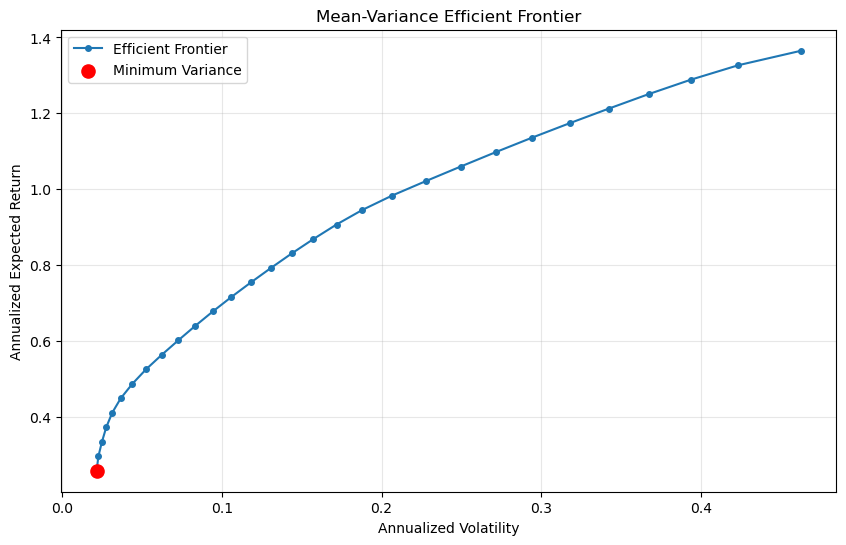

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    frontier_df["volatility"],
    frontier_df["expected_return"],
    marker="o",
    markersize=4,
    label="Efficient Frontier"
)

plt.scatter(
    np.sqrt(
        min_var_weights.to_numpy()
        @ cov_matrix.to_numpy()
        @ min_var_weights.to_numpy()
    ) * np.sqrt(12),
    min_return * 12,
    color="red",
    s=90,
    label="Minimum Variance",
    zorder=5
)

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Expected Return")
plt.title("Mean-Variance Efficient Frontier")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [48]:
# One final thing: combine the statistics from the value and momentum portfolios to this table as well (results from using the long-short strategy). We must make the months align, though
# The code here is mostly just copy & paste with all the methods

all_portfolio_returns = (
    portfolio_returns
    .merge(
        momentum_factor_returns[["month", "momentum_factor_return"]],
        on="month",
        how="inner"
    )
    .merge(
        value_factor_returns[["month", "value_factor_return"]],
        on="month",
        how="inner"
    )
)

return_columns = list(weight_methods.values()) + [
    "momentum_factor_return",
    "value_factor_return"
]

all_portfolio_returns = (
    all_portfolio_returns
    .dropna(subset=return_columns)
    .sort_values("month")
    .reset_index(drop=True)
)

performance = {}
benchmark_metrics = {}

for column in return_columns:

    performance[column] = compute_risk_metrics(
        all_portfolio_returns,
        return_column=column,
        portfolio_type="factor"
    )

    benchmark_metrics[column] = calculate_benchmark_metrics(
        all_portfolio_returns,
        spy_monthly,
        portfolio_return_column=column
    )

performance_df = pd.DataFrame(performance).T

benchmark_metrics_df = pd.DataFrame(benchmark_metrics).T

performance_df = performance_df.join(benchmark_metrics_df)

performance_df["avg_monthly_turnover"] = np.nan

common_months = all_portfolio_returns["month"]

portfolio_common = portfolio_clean[
    portfolio_clean["month"].isin(common_months)
].copy()

for weight_col, return_col in weight_methods.items():

    turnover_df = calculate_turnover(
        portfolio_common,
        weight_column=weight_col,
        return_column="monthly_simple_return"
    )

    performance_df.loc[
        return_col,
        "avg_monthly_turnover"
    ] = turnover_df["turnover"].mean()

In [72]:
# Turnover calculations for momentum and value factors are different:

def calculate_factor_weights(df):
    """
    Short function that calculates turnover for momentum & value portfolios

    Input:
        df: dataframe of momentum/value portfolio
    Output:
        dataframe with added factor weight column
    """
    df = df.copy()

    df["factor_weight"] = 0.0

    long_count = df.groupby("month")["quintile"].transform(
        lambda x: (x == 5).sum()
    )

    short_count = df.groupby("month")["quintile"].transform(
        lambda x: (x == 1).sum()
    )

    df.loc[df["quintile"] == 5, "factor_weight"] = (
        1 / long_count[df["quintile"] == 5]
    )

    df.loc[df["quintile"] == 1, "factor_weight"] = (
        -1 / short_count[df["quintile"] == 1]
    )

    return df

def calculate_factor_target_turnover(df):
    """
    Short function that calculates turnover given a dataframe with factor weights

    Input:
        df: dataframe with factor weights
    Output:
        turnover value
    """
    weights_wide = (
        df.pivot(
            index="month",
            columns="ticker",
            values="factor_weight"
        )
        .sort_index()
        .fillna(0)
    )

    turnover = (
        weights_wide.diff()
        .abs()
        .sum(axis=1)
        / 2
    )

    turnover.iloc[0] = np.nan

    return turnover
    
momentum_positions = calculate_factor_weights(momentum_quintiles)
value_positions = calculate_factor_weights(value_quintiles)

for positions in [momentum_positions, value_positions]: # Shift to calculate the right thing
    positions["month"] = positions["month"] + 1

momentum_turnover = calculate_factor_target_turnover(
    momentum_positions
)

value_turnover = calculate_factor_target_turnover(
    value_positions
)

# Step 4: Add average turnover to the comparison table
performance_df.loc[
    "momentum_factor_return",
    "avg_monthly_target_turnover"
] = momentum_turnover[
    momentum_turnover.index.isin(common_months)
].mean()

performance_df.loc[
    "value_factor_return",
    "avg_monthly_target_turnover"
] = value_turnover[
    value_turnover.index.isin(common_months)
].mean()

comparison_columns = [
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "beta",
    "information_ratio",
    "tracking_error",
    "avg_monthly_turnover",
    "avg_monthly_target_turnover"
]
display(performance_df[comparison_columns].round(4))

# The turnovers are in different columns because they're technically not the same thing:
    # For the value & momentum strategies, we're actively having a target allocation based on previous month's factor calculations.
    # For the other strategies, despite target allocations often not changing, we still have to rebalance due to return changes (and the rule for that corresponding portfolio).

,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,beta,information_ratio,tracking_error,avg_monthly_turnover,avg_monthly_target_turnover
ew_return,0.2627,0.1678,1.5659,-0.2201,1.0451,2.2949,0.0421,0.0292,NaN
inv_vol_return,0.2212,0.1481,1.4936,-0.2143,0.9242,1.5869,0.0375,0.0417,NaN
rp_return,0.2250,0.1447,1.5555,-0.2036,0.8548,1.0147,0.0614,0.1545,NaN
min_var_return,0.2355,0.1365,1.7257,-0.2304,0.7158,0.7708,0.0905,0.2474,NaN
shrunk_min_var_return,0.2236,0.1339,1.6705,-0.2289,0.7120,0.6804,0.0875,0.2280,NaN
momentum_factor_return,0.0094,0.2917,0.0322,-0.4442,0.0974,-0.3176,0.3234,NaN,0.4597
value_factor_return,0.0345,0.1581,0.2185,-0.1927,-0.2455,-0.4291,0.2471,NaN,0.1302


# Task 5

In addition to the above analyses, we can create a few more charts to visualize these portfolios in action. I've chosen a few to plot.

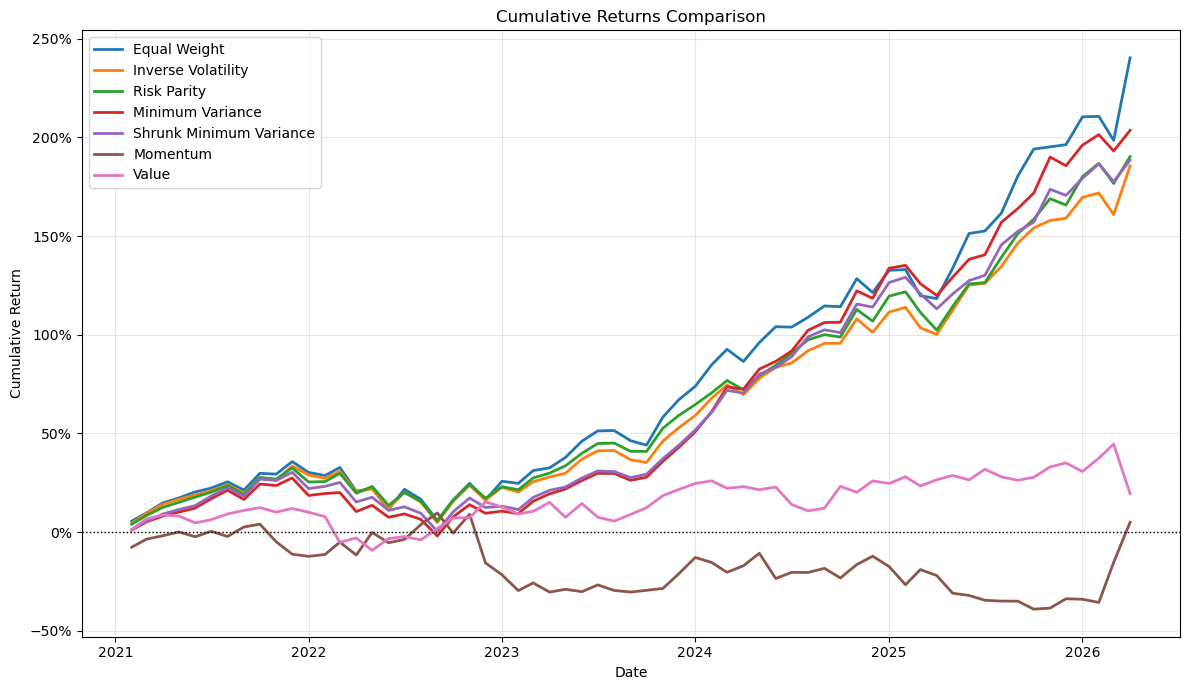

In [67]:
# Cumulative return plot

portfolio_colors = {
    "ew_return": "tab:blue",
    "inv_vol_return": "tab:orange",
    "rp_return": "tab:green",
    "min_var_return": "tab:red",
    "shrunk_min_var_return": "tab:purple",
    "momentum_factor_return": "tab:brown",
    "value_factor_return": "tab:pink"
}

return_columns = list(weight_methods.values()) + [
    "momentum_factor_return",
    "value_factor_return"
]

chart_df = (
    all_portfolio_returns[["month"] + return_columns]
    .dropna()
    .sort_values("month")
    .copy()
)

for column in return_columns:
    chart_df = add_cumulative_returns(
        chart_df,
        column,
        "cumulative_" + column
    )

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

labels = {
    "ew_return": "Equal Weight",
    "inv_vol_return": "Inverse Volatility",
    "rp_return": "Risk Parity",
    "min_var_return": "Minimum Variance",
    "shrunk_min_var_return": "Shrunk Minimum Variance",
    "momentum_factor_return": "Momentum",
    "value_factor_return": "Value"
}

plt.figure(figsize=(12, 7))

for column in return_columns:
    plt.plot(
        chart_df["month"].dt.to_timestamp(),
        chart_df["cumulative_" + column],
        label=labels[column],
        color=portfolio_colors[column],
        linewidth=2
    )

plt.axhline(0, color="black", linestyle=":", linewidth=1)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Cumulative Returns Comparison")

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "cumulative_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

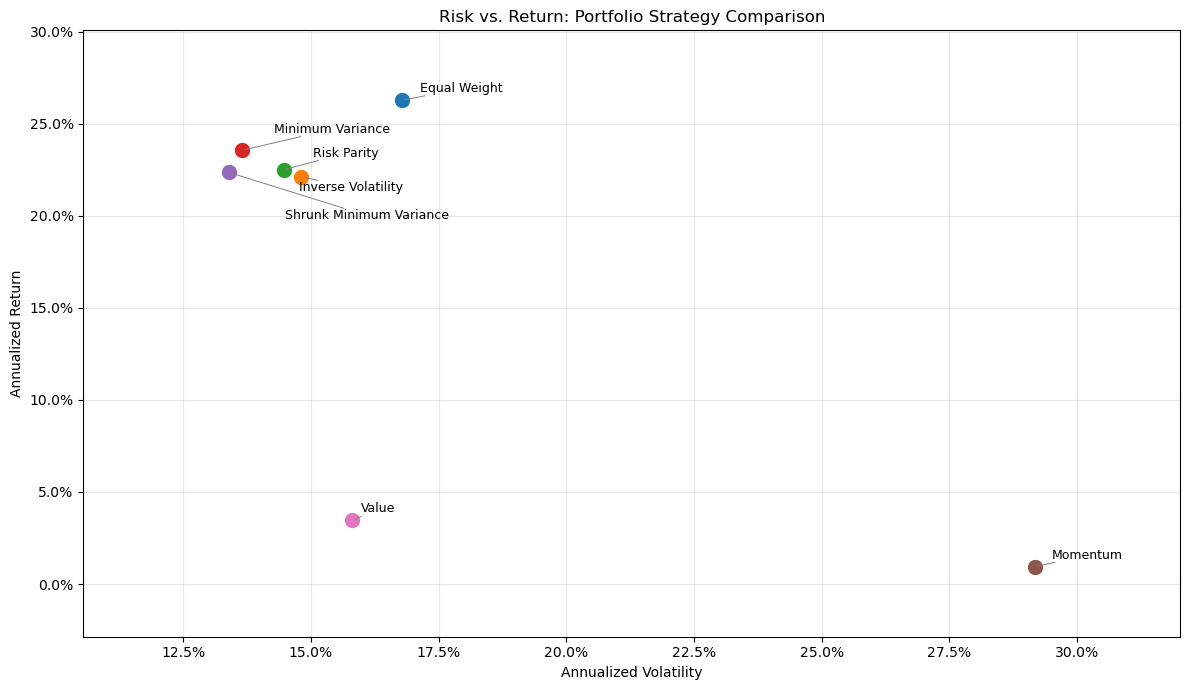

In [68]:
# Scatterplot showing annualized volatility vs return:

fig, ax = plt.subplots(figsize=(12, 7))

texts = []

for portfolio, row in performance_df.iterrows():

    x = row["annualized_volatility"]
    y = row["annualized_return"]

    ax.scatter(
        x, y,
        s=100,
        color=portfolio_colors[portfolio]
    )

    texts.append(
        ax.text(
            x, y,
            labels.get(portfolio, portfolio),
            fontsize=9
        )
    )

# Add space around the data for labels
ax.margins(x=0.18, y=0.15)

# Automatically reposition labels
adjust_text(
    texts,
    ax=ax,
    expand=(1.3, 1.5),
    force_text=(0.8, 1.0),
    force_static=(0.8, 1.0),
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=0.7
    )
)

ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Annualized Return")
ax.set_title("Risk vs. Return: Portfolio Strategy Comparison")

ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "risk_return_scatterplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

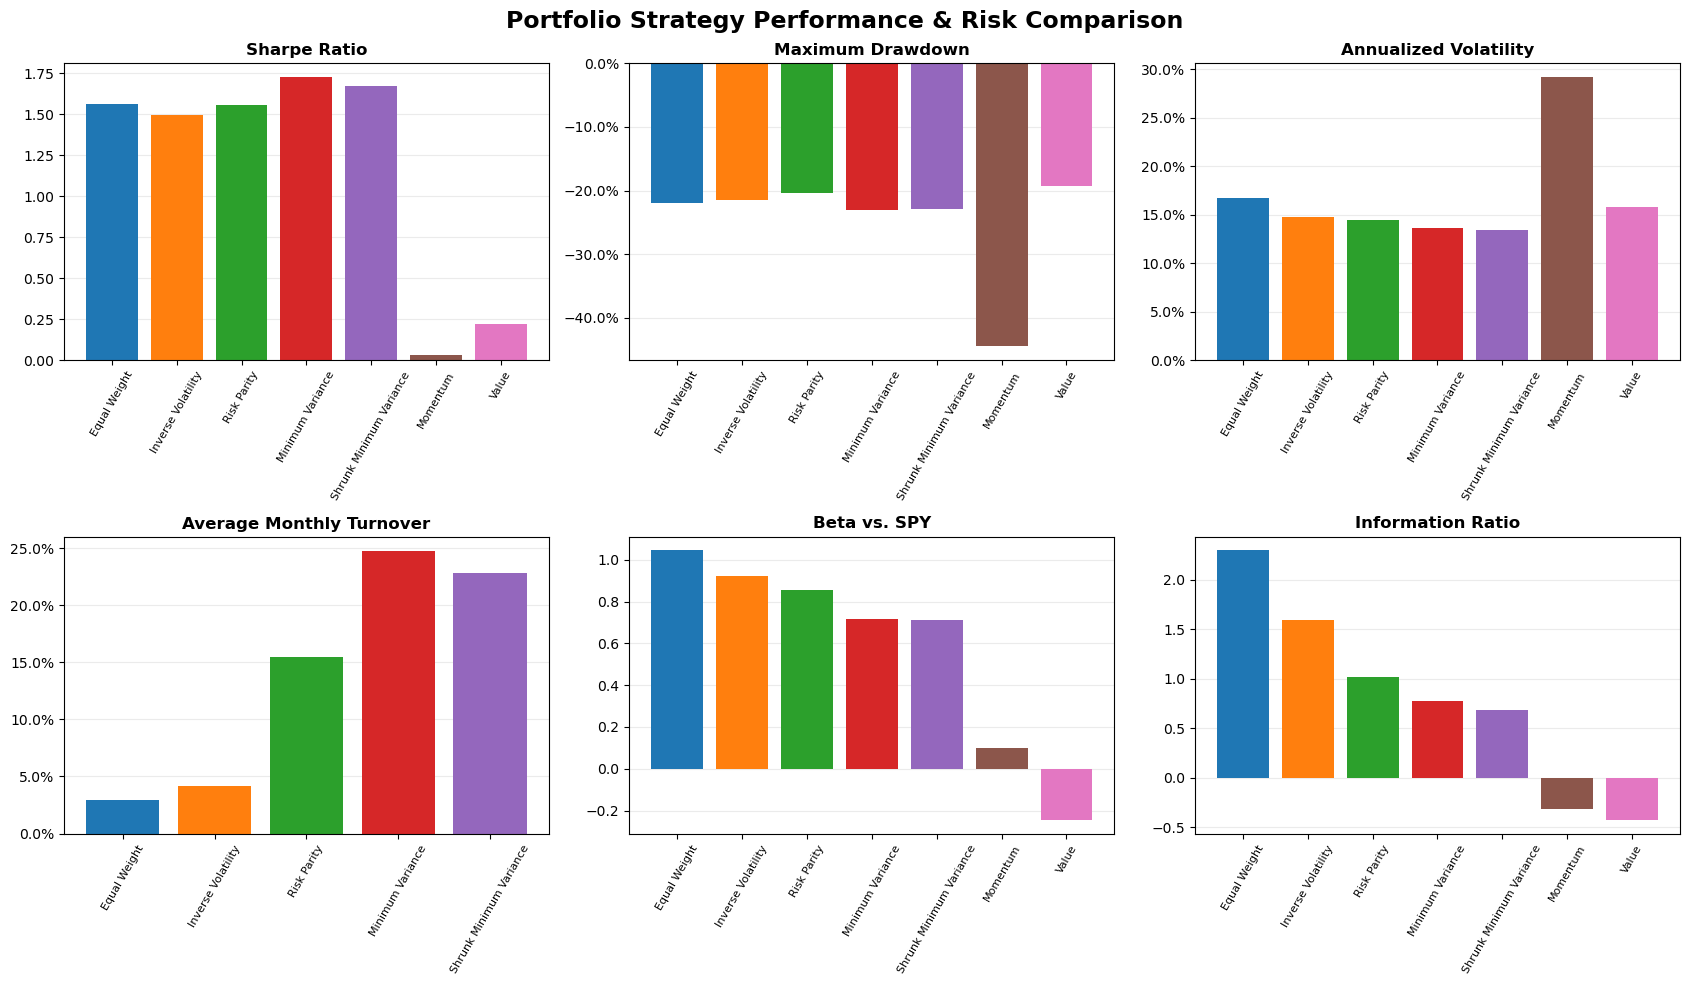

In [70]:
# Metrics to display: column name -> (title, percentage?)
metrics = {
    "sharpe_ratio": ("Sharpe Ratio", False),
    "max_drawdown": ("Maximum Drawdown", True),
    "annualized_volatility": ("Annualized Volatility", True),
    "avg_monthly_turnover": ("Average Monthly Turnover", True),
    "beta": ("Beta vs. SPY", False),
    "information_ratio": ("Information Ratio", False)
}

# Keep only portfolios in our comparison
plot_df = performance_df.loc[
    performance_df.index.intersection(labels.keys())
].copy()

# Preserve the original column names for color mapping
plot_df["color"] = plot_df.index.map(portfolio_colors)

# Rename indices for display
plot_df.index = plot_df.index.map(labels)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for ax, (column, (title, is_percent)) in zip(axes, metrics.items()):

    values = plot_df[column].dropna()

    ax.bar(
        values.index,
        values,
        color=plot_df.loc[values.index, "color"]
    )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=60, labelsize=8)

    if is_percent:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

fig.suptitle(
    "Portfolio Strategy Performance & Risk Comparison",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "portfolio_metrics_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()